In [1]:
from src.eval.symantic.embedding_utils import get_documents_embeds

In [2]:
from src.documents_analysis.utils import reduce_dimensionality, discover_clusters, visualize_clusters

In [3]:
fairy_tales_embeds_3 = get_documents_embeds('GEM/FairytaleQA', split_name='train', batch_size=1, column_name='content', debug_samples=20)

`torch_dtype` is deprecated! Use `dtype` instead!


loading embedder model and tokenizer...


Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

embedder model loaded


Using the latest cached version of the dataset since GEM/FairytaleQA couldn't be found on the Hugging Face Hub
2025-11-03 16:15:43,108 - WARNING - Using the latest cached version of the dataset since GEM/FairytaleQA couldn't be found on the Hugging Face Hub
Found the latest cached dataset configuration 'default' at /home/brimmann/.cache/huggingface/datasets/GEM___fairytale_qa/default/1.0.0/915cb13387fb0028e0fd29b7f156905e3afb99ba1d58c88d6c54a4e550c8678b (last modified on Tue Oct 14 16:53:41 2025).
2025-11-03 16:15:43,125 - WARNING - Found the latest cached dataset configuration 'default' at /home/brimmann/.cache/huggingface/datasets/GEM___fairytale_qa/default/1.0.0/915cb13387fb0028e0fd29b7f156905e3afb99ba1d58c88d6c54a4e550c8678b (last modified on Tue Oct 14 16:53:41 2025).


dataset_id is not None
generating embeddings...


Preparing retrieval embeds: 100%|██████████| 20/20 [00:14<00:00,  1.41it/s]

embeddings generated


In [7]:
import torch

In [8]:
fairy_tales_embeds_3 = torch.stack([t[0] for t in fairy_tales_embeds_3]).to(torch.float32).numpy()

In [9]:
fairy_tales_embeds_3.shape

(20, 4096)

In [10]:
reduced_embeddings = reduce_dimensionality(fairy_tales_embeds_3)

2025-11-03 16:16:55,395 - INFO - Starting UMAP dimensionality reduction...
/home/brimmann/works/xRAG/.venv/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP(angular_rp_forest=True, metric='cosine', n_jobs=1, random_state=42, verbose=True)
Mon Nov  3 16:16:55 2025 Construct fuzzy simplicial set
Mon Nov  3 16:16:55 2025 Finding Nearest Neighbors
Mon Nov  3 16:16:58 2025 Finished Nearest Neighbor Search
Mon Nov  3 16:16:59 2025 Construct embedding


Epochs completed:   0%|            0/500 [00:00]

2025-11-03 16:17:00,268 - INFO - UMAP reduction complete.


	completed  0  /  500 epochs
	completed  50  /  500 epochs
	completed  100  /  500 epochs
	completed  150  /  500 epochs
	completed  200  /  500 epochs
	completed  250  /  500 epochs
	completed  300  /  500 epochs
	completed  350  /  500 epochs
	completed  400  /  500 epochs
	completed  450  /  500 epochs
Mon Nov  3 16:17:00 2025 Finished embedding


In [11]:
discovered_labels = discover_clusters(reduced_embeddings)

2025-11-03 16:17:02,500 - INFO - Starting cluster discovery with HDBSCAN...
/home/brimmann/works/xRAG/.venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/brimmann/works/xRAG/.venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
2025-11-03 16:17:02,522 - INFO - HDBSCAN found 2 clusters and 0 noise points.


In [12]:
OUTPUT_FILENAME = "discovered_document_clusters.png"

2025-11-03 16:17:11,126 - INFO - Generating visualization...
2025-11-03 16:17:11,549 - INFO - Cluster visualization saved to discovered_document_clusters.png


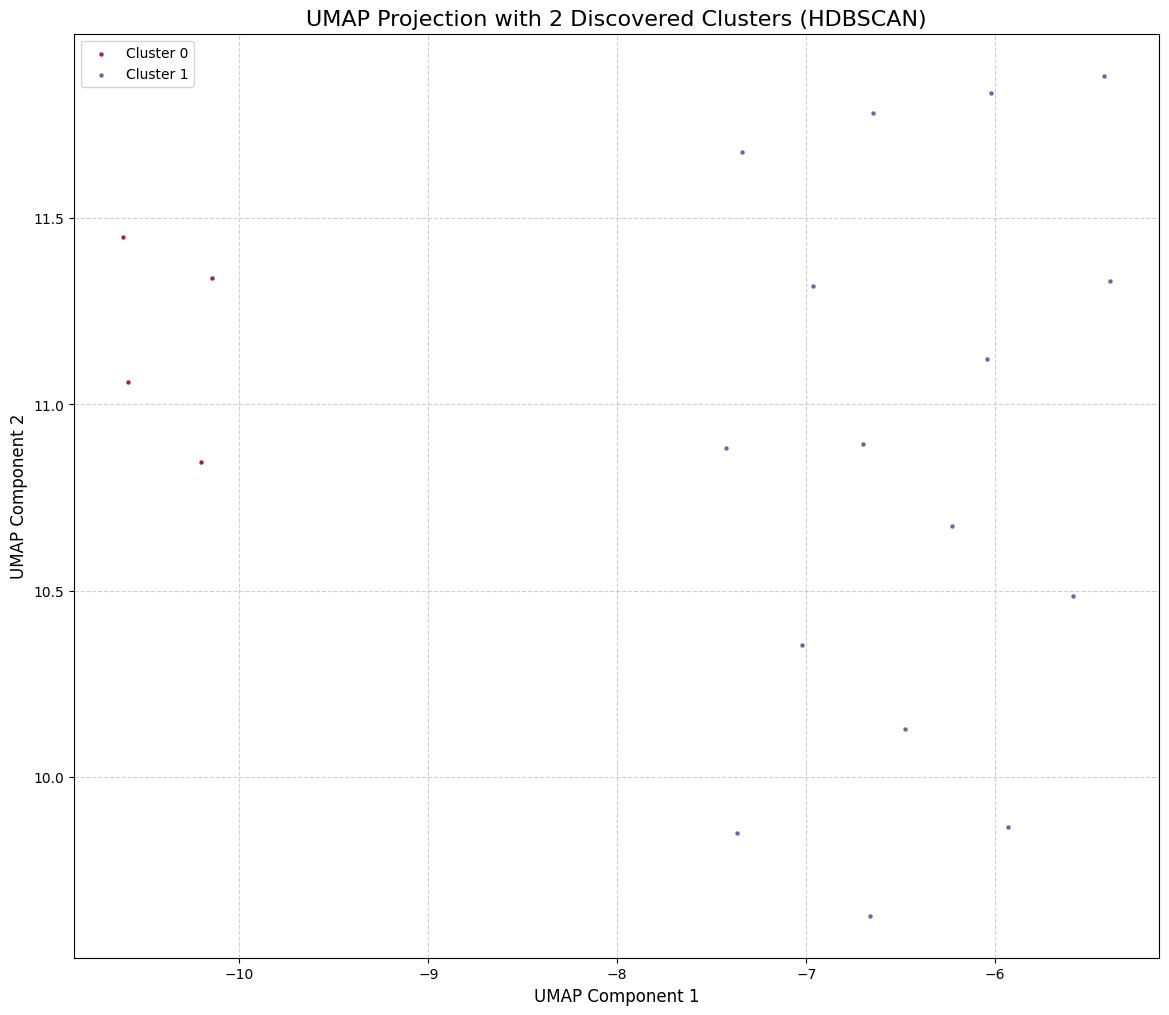

In [13]:
visualize_clusters(reduced_embeddings, discovered_labels, OUTPUT_FILENAME)